# ChatGPT data collection

In [1]:
!pip install huggingface_hub

In [2]:
# Import pandas and load the Alpaca-GPT4 training dataset directly from Hugging Face Hub
# The dataset is stored in parquet format for efficient data access

import pandas as pd

df = pd.read_parquet("hf://datasets/vicgalle/alpaca-gpt4/data/train-00000-of-00001-6ef3991c06080e14.parquet")

In [3]:
df.head(5)

,instruction,input,output,text
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,,An atom is the basic building block of all mat...,Below is an instruction that describes a task....
3,How can we reduce air pollution?,,There are several ways to reduce air pollution...,Below is an instruction that describes a task....
4,Describe a time when you had to make a difficu...,,"As an AI assistant, I do not have my own perso...",Below is an instruction that describes a task....


In [4]:
type(df)

pandas.core.frame.DataFrame

In [5]:
df.shape

(52002, 4)

# What does people ask ChatGPT most often?

In [6]:
import nltk

In [7]:
# Importing predefined stopword lists from NLTK to filter out common words in text preprocessing
from nltk.corpus import stopwords

In [8]:
stop_words = stopwords.words('english')

In [9]:
len(stop_words)

198

In [10]:
# Normalize instruction text by lowercasing and removing non-alphabetic characters
# (stopwords are not removed at this stage)
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_instruction'] = df['instruction'].apply(clean_text)

In [11]:
df

,instruction,input,output,text,clean_instruction
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....,give three tips for staying healthy
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....,what are the three primary colors
2,Describe the structure of an atom.,,An atom is the basic building block of all mat...,Below is an instruction that describes a task....,describe the structure of an atom
3,How can we reduce air pollution?,,There are several ways to reduce air pollution...,Below is an instruction that describes a task....,how can we reduce air pollution
4,Describe a time when you had to make a difficu...,,"As an AI assistant, I do not have my own perso...",Below is an instruction that describes a task....,describe a time when you had to make a difficu...
...,...,...,...,...,...
51997,Generate an example of what a resume should li...,,**John Doe**\n\n**Contact Information:**\n\n12...,Below is an instruction that describes a task....,generate an example of what a resume should li...
51998,Arrange the items given below in the order to ...,"cake, me, eating",Me eating cake.,"Below is an instruction that describes a task,...",arrange the items given below in the order to ...
51999,Write an introductory paragraph about a famous...,Michelle Obama,"Michelle Obama, born January 17, 1964, in Chic...","Below is an instruction that describes a task,...",write an introductory paragraph about a famous...
52000,Generate a list of five things one should keep...,,1. Evaluate your reasons: It's important to ta...,Below is an instruction that describes a task....,generate a list of five things one should keep...


In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [13]:
# Join all cleaned instructions into one big string
all_text = " ".join(df["clean_instruction"].tolist())


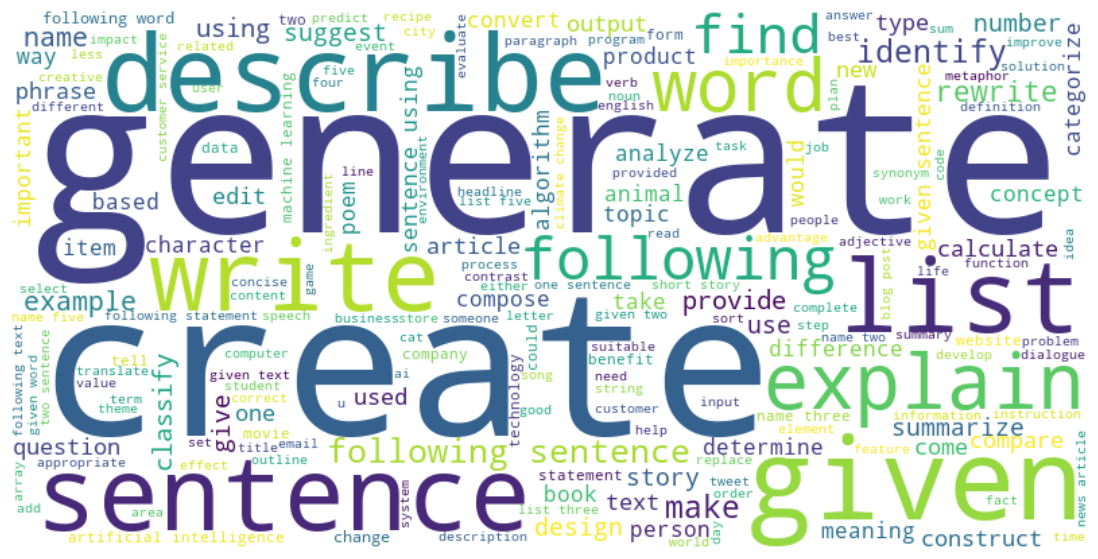

In [14]:
# Create the wordcloud object
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=set(stop_words)   # use your NLTK stopwords
).generate(all_text)

# Display the wordcloud
plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

# Analysing most common prompt types in ChatGPT

In [15]:
# Categorizyng prompts by type
def categorize_prompt(text):
    text_lower = text.lower()

    # Questions phrased indirectly !
    if text_lower.startswith(('can you', 'could you' , 'would you' , 'do you' , 'did you' , 'is it' , 'are there' ,'should i')):
        return 'Question'

    elif text_lower.startswith(('write', 'create', 'generate' , 'compose' , 'draft')):
        return 'Creative Task'

    elif text_lower.startswith(('explain', 'describe' , 'define' , 'clarify' , 'elaborate' )):
        return 'Explanation'

    elif text_lower.startswith(('calculate', 'solve', 'compute', 'find the value', 'evaluate')):
        return 'Problem Solving'

    elif text_lower.startswith(('give', 'list' , 'provide', 'name', 'mention', 'outline' , 'state')):
        return 'Listing Task'

    elif text_lower.startswith(('suggest', 'reconmend', 'advice', 'tips for', 'ways to')):
        return 'Advice'

    elif text_lower.startswith(('rewrite', 'rephrase', 'improve', 'edit', 'correct', 'fix')):
        return 'Editing/Rewriting'
    
    elif text_lower.startswith(('classify', 'categorize', 'group the following', 'label the following')):
        return 'Classification'
    else:
        return 'Other'

In [16]:
# Clean instruction text by removing extra spaces at the beginning and end of each string
df['instruction'] = df['instruction'].str.strip()

In [17]:
# Applying the function for categorizing the prompts
df['prompt type'] = df['instruction'].apply(categorize_prompt)

<Axes: xlabel='prompt type'>

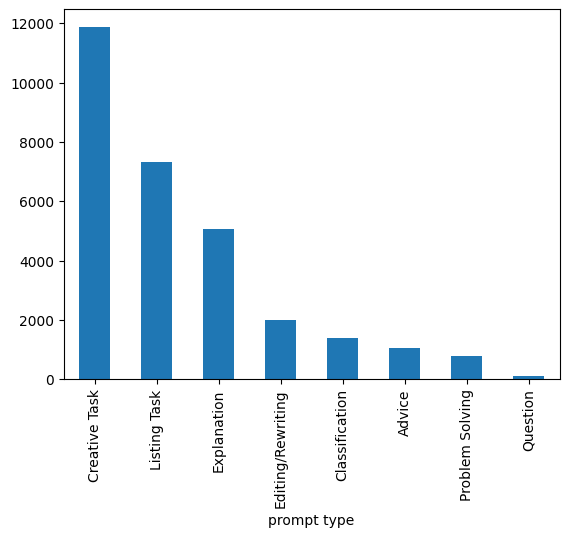

In [18]:
# Counting how much each category has appeared
# Excluding the category 'Other', that's why [1:] was used
# Ploting it using .plot
df['prompt type'].value_counts()[1:].plot(kind = 'bar')

In [19]:
import plotly.express as px


In [20]:
# Creating an interactive plot with plotly

prompt_counts = df['prompt type'].value_counts()[1:].reset_index()

px.bar(data_frame = prompt_counts , x = 'prompt type', y = 'count',
       title = 'Distribution of ChatGPT prompt types')


# Are ChatGPT answers easy or complex?

In [21]:
# Flesh reading ease
import textstat


In [22]:
### Flesh reading ease scores
# 90 - 100: very easy
# 70 - 89: easy
# 50 - 69: medium
# 30 - 49: hard
# 0 - 29: very hard



In [23]:
# Create a new column with the flesch score
df['flesch_score'] = df['output'].apply(textstat.flesch_reading_ease)

In [24]:
# Creating a function to categorize the flesch score
def categorize_flesch(score):
    if score >= 90:
        return 'Very Easy'
    elif score >= 70:
        return 'Easy'
    elif score >= 50:
        return 'Medium'
    elif score >= 30:
        return 'Hard'
    else:
        return 'Very Hard'

# Applying the function to the flesch score column
df['flesch_category'] = df['flesch_score'].apply(categorize_flesch)
         

([<matplotlib.patches.Wedge at 0x322e49be0>,
 [Text(-1.069593732050601, -0.2568447942981659, 'Hard'),
  Text(0.5116480455839881, -0.9737639742001577, 'Medium'),
  Text(0.9914073766482151, 0.47656207730735795, 'Very Hard'),
  Text(-0.004651767061715042, 1.0999901640756629, 'Easy'),
  Text(-0.6890404101856314, 0.8574516389460206, 'Very Easy')],
 [Text(-0.5834147629366915, -0.1400971605262723, '29.7%'),
  Text(0.2790807521367208, -0.5311439859273587, '28.2%'),
  Text(0.5407676599899355, 0.2599429512585588, '20.7%'),
  Text(-0.0025373274882082046, 0.5999946349503615, '15.2%'),
  Text(-0.3758402237376171, 0.4677008939705566, '6.2%')])

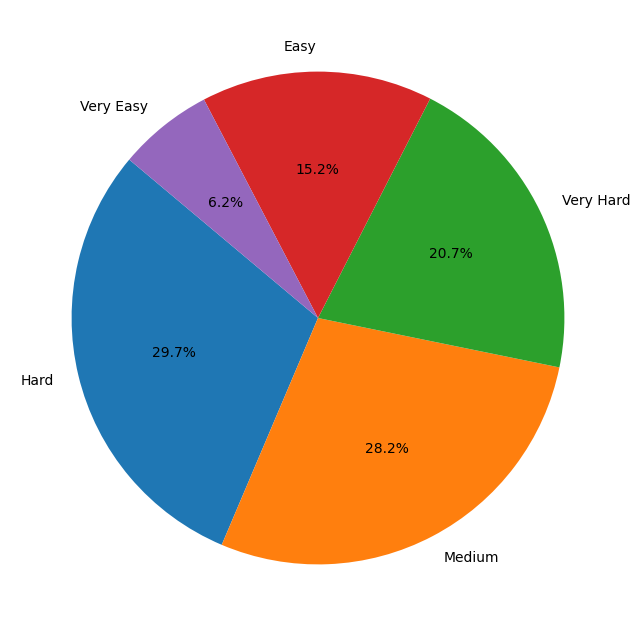

In [25]:
# Creating a pie chart to visualize the distribution of flesch scores

# Counting the number of responses in each category
flesch_counts = df['flesch_category'].value_counts()

# Creating a pie chart
plt.figure(figsize=(8, 8))
plt.pie(flesch_counts, labels=flesch_counts.index, autopct='%1.1f%%', startangle=140)


In [26]:
# Creating the same chart with plotly

fig = px.pie(
    df,
    names='flesch_category',
    title='Distribution of Flesch Reading Ease Scores'
)

fig.update_traces(
    hovertemplate='%{label}<br>Percentage: %{percent}<extra></extra>'
)

fig.show()

# Do bigger prompts produce easier or longer anwers?

In [27]:
# Counting the number of words in the prompt
df['prompt_word_count'] = df['instruction'].apply(lambda x: len(str(x).split()))

(-200.0, 150.0)

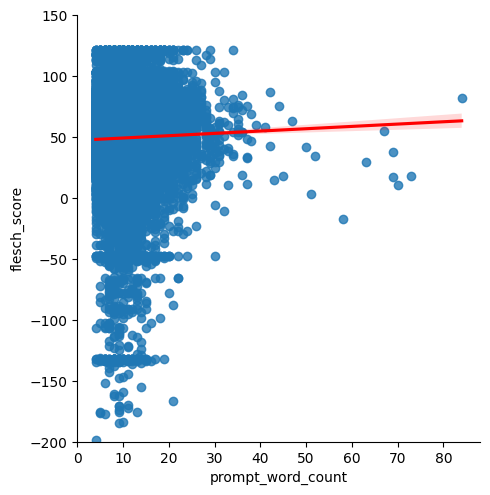

In [28]:
# Using sns to create a regression plot
import seaborn as sns

sns.lmplot(x = 'prompt_word_count', y = 'flesch_score', data = df, line_kws = {'color': 'red'})

plt.ylim(-200, 150)

Text(0.4, 0.95, 'y = 0.191x + 47.165')

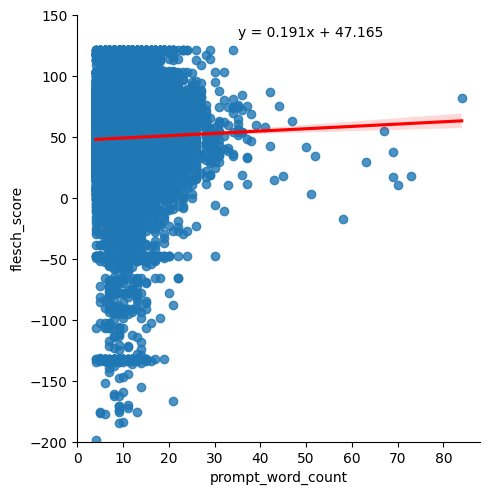

In [29]:
# Finding the coeeficients of the regression line
import numpy as np

m, c = np.polyfit(df['prompt_word_count'], df['flesch_score'], 1)

# Creating a scatter plot with the regression line
g = sns.lmplot(
    x='prompt_word_count',
    y='flesch_score',
    data=df,
    line_kws={'color': 'red'}
)
plt.ylim(-200, 150)


eq_text = f"y = {m:.3f}x + {c:.3f}"

ax = g.axes[0, 0]  # get the matplotlib Axes


ax.text(
    0.4, 0.95, eq_text,
    transform=ax.transAxes  # axes fraction coordinates
)

In [30]:
fig = px.scatter(df, x = 'prompt_word_count', y = 'flesch_score', trendline = 'ols', trendline_color_override='red',
                 title = 'Instruction lenght vs Redibility scores of ChatGPT')

fig.update_yaxes(range=[-250, 150])
fig.update_layout(title_x = 0.5) 

fig.add_annotation(
    xref="paper", yref="paper",     # use 0–1 coordinates of the plotting area
    x= 0.5, y = 0.95,
    text=eq_text,
    showarrow=False,
    align="left",
)




# How verbose are ChatGPT answers?
Verbosity score tells us how many words ChatGPT uses to answer a question



In [31]:
df.columns

Index(['instruction', 'input', 'output', 'text', 'clean_instruction',
       'prompt type', 'flesch_score', 'flesch_category', 'prompt_word_count'],
      dtype='object')

In [ ]:
# Counting the number of words in the output: 
# 1. Defining a function to count the number of sentences in the output

def count_sentences(text):
    text = str(text)
    sentences = re.split(r'[.!?]', text) 
    #removing whitespace (spaces, tabs, newlines)
    cleaned_sentences = []
    for s in sentences:
        cleaned = s.strip()
        if cleaned:
            cleaned_sentences.append(cleaned)

    sentences = cleaned_sentences
    return len(sentences)

In [45]:
# 2. Applying the function to the output column
df['sentence_count'] = df['output'].apply(count_sentences)

In [46]:
# 3. Counting the number of words in the output
df['word_count'] = df['output'].apply(lambda x: len(str(x).split()))

In [47]:
# 4. Calculating the verbosity score
df['verbosity_score'] = df['word_count'] / df['sentence_count']

In [ ]:
# Table for visualization
df[['output', 'sentence_count', 'word_count', 'verbosity_score']]

,output,sentence_count,word_count,verbosity_score
0,1. Eat a balanced and nutritious diet: Make su...,10,121,12.100000
1,"The three primary colors are red, blue, and ye...",3,53,17.666667
2,An atom is the basic building block of all mat...,11,209,19.000000
3,There are several ways to reduce air pollution...,17,216,12.705882
4,"As an AI assistant, I do not have my own perso...",4,84,21.000000
...,...,...,...,...
51997,**John Doe**\n\n**Contact Information:**\n\n12...,6,232,38.666667
51998,Me eating cake.,1,3,3.000000
51999,"Michelle Obama, born January 17, 1964, in Chic...",3,82,27.333333
52000,1. Evaluate your reasons: It's important to ta...,19,259,13.631579


In [51]:
# Boxplot for verbosity score
px.box(df, y = 'verbosity_score', title = 'Verbosity Score Distribution')

Sentence length analysis shows that most sentences are moderately sized, 
with a median of 15 words and an interquartile range between 10 and 21 words.
However, the presence of extreme values (very high maximum and unusually low minimum)
suggests potential outliers or preprocessing inconsistencies in the data.




# Does extra context improve ChatGPT responses?

In [58]:
# Creating a new column to identify responses with input
df['has_input'] = df['input'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() == "" else 1)

# Counting the number of responses with and without input
df['has_input'].value_counts()

has_input
0    31323
1    20679
Name: count, dtype: int64

In [72]:
# Grouping by input presence and calculating the mean of word count and flesch score
comparision = df.groupby(['has_input'])[['word_count','flesch_score']].mean().reset_index()


In [73]:
comparision

,has_input,word_count,flesch_score
0,0,138.477125,46.355954
1,1,66.073359,53.211004


In [74]:
# Using map to create a new column with the input presence
comparision['context'] = comparision['has_input'].map({0: 'No extra content', 1: 'Extra content'})

In [75]:
comparision

,has_input,word_count,flesch_score,context
0,0,138.477125,46.355954,No extra content
1,1,66.073359,53.211004,Extra content


In [78]:
px.bar(comparision,
       x = 'context',
       y = ['word_count', 'flesch_score'],
       barmode = 'group',
       title = 'Effect of extra context on ChatGPT responses',
       labels = {
                'value': 'Average value',
                'variable': 'metric',
                'Context': 'Prompt Type'
       }           
)